## Transfer Learning

#### 1. Setup and Imports

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.getcwd())
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'src')):
    PROJECT_ROOT = os.path.abspath('..')

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

import torch
import wandb
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from src.dataset import get_dataloaders
from src.models import TransferResNet18
from src.utils import generate_run_name, log_confusion_matrix, EarlyStopping, EMOTION_LABELS, load_wandb_results
from src.train import train

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
wandb.login()
print('Wandb ready')


Project root: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\l.chitishvili\_netrc.


Using device: cuda


wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Wandb ready


#### 2. Data Loading

In [2]:
for aug in ['none', 'light', 'strong']:
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir=DATA_DIR,
        aug_mode=aug,
        batch_size=64
    )
    images, labels = next(iter(train_loader))
    print(f'aug={aug} | batch shape: {images.shape} | labels shape: {labels.shape}')

print('Data loading works correctly')


aug=none | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=light | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=strong | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
Data loading works correctly


#### 3. Model Definition

In [3]:
model = TransferResNet18(mode='frozen')
dummy = torch.randn(4, 1, 48, 48)
out = model(dummy)
print(f'TransferResNet18 output shape: {out.shape}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


TransferResNet18 output shape: torch.Size([4, 7])
Total parameters: 11,180,103
Trainable parameters: 3,591


#### 3b. Forward and Backward Check

In [4]:
model = TransferResNet18(mode='frozen')
train_loader, _, _ = get_dataloaders(data_dir=DATA_DIR, aug_mode='none', batch_size=4)
images, labels = next(iter(train_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

model = model.to(DEVICE)
out = model(images)
assert out.shape == (images.size(0), 7), f"Expected (batch, 7), got {out.shape}"
assert not torch.isnan(out).any() and not torch.isinf(out).any(), "Forward pass produced NaN/inf"

loss = torch.nn.functional.cross_entropy(out, labels)
model.zero_grad()
loss.backward()

trainable = [name for name, p in model.named_parameters() if p.requires_grad]
bad = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.grad is None:
        bad.append(f"{name}: no grad")
    elif torch.isnan(p.grad).any() or torch.isinf(p.grad).any():
        bad.append(f"{name}: NaN/inf grad")
    elif p.grad.abs().sum() == 0:
        bad.append(f"{name}: zero grad")

assert trainable, "Expected at least one trainable parameter"
assert not bad, "Backward check failed:\n" + "\n".join(bad)
print(f"Forward OK: output {tuple(out.shape)}, loss={loss.item():.4f}")
print(f"Backward OK: gradients on {len(trainable)} trainable parameter group(s)")


Forward OK: output (4, 7), loss=2.5147
Backward OK: gradients on 2 trainable parameter group(s)


#### 4. Hyperparameter Setup

In [4]:
CONFIGS = [
    # ── frozen backbone — only head trains ──
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.01_bs64_noaug',    'lr': 0.01,    'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.001_bs64_noaug',   'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.0003_bs64_noaug',  'lr': 0.0003,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.001_bs64_light',   'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'light',  'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.001_bs64_strong',  'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'strong', 'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.001_bs32_noaug',   'lr': 0.001,   'optimizer': 'adam', 'batch_size': 32,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.001_bs128_noaug',  'lr': 0.001,   'optimizer': 'adam', 'batch_size': 128, 'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_sgd_0.01_bs64_noaug',     'lr': 0.01,    'optimizer': 'sgd',  'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 10, 'mode': 'frozen'},
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.001_bs64_noaug_wd1e-4', 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'none', 'dropout': 0.0, 'weight_decay': 1e-4, 'scheduler': False, 'epochs': 10, 'mode': 'frozen'},

    # ── finetune — all layers train with small lr ──
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-4_bs64_noaug',   'lr': 1e-4,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 15, 'mode': 'finetune'},
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_3e-5_bs64_noaug',   'lr': 3e-5,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 15, 'mode': 'finetune'},
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-5_bs64_noaug',   'lr': 1e-5,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 15, 'mode': 'finetune'},
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-4_bs64_light',   'lr': 1e-4,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'light',  'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 15, 'mode': 'finetune'},
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-4_bs64_strong',  'lr': 1e-4,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'strong', 'dropout': 0.0, 'weight_decay': 0,    'scheduler': False, 'epochs': 15, 'mode': 'finetune'},
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-4_bs64_strong_wd1e-4', 'lr': 1e-4, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong', 'dropout': 0.0, 'weight_decay': 1e-4, 'scheduler': False, 'epochs': 15, 'mode': 'finetune'},
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-4_bs64_strong_sched',  'lr': 1e-4, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong', 'dropout': 0.0, 'weight_decay': 0,    'scheduler': True,  'epochs': 20, 'mode': 'finetune'},

    # ── deliberate overfit ──
    {'arch': 'transfer', 'run_name': 'transfer_finetune_adam_1e-3_bs32_noaug_overfit',   'lr': 1e-3,  'optimizer': 'adam', 'batch_size': 32,  'aug': 'none',   'dropout': 0.0, 'weight_decay': 0, 'scheduler': False, 'epochs': 30, 'mode': 'finetune'},

    # ── deliberate underfit ──
    {'arch': 'transfer', 'run_name': 'transfer_frozen_adam_0.0001_bs128_noaug_underfit', 'lr': 0.0001,'optimizer': 'adam', 'batch_size': 128, 'aug': 'none',   'dropout': 0.0, 'weight_decay': 0, 'scheduler': False, 'epochs': 3,  'mode': 'frozen'},
]

print(f'Total runs planned: {len(CONFIGS)}')


Total runs planned: 18


#### 5. Training

In [ ]:
all_results = []
RESULTS_PATH = os.path.join(CHECKPOINT_DIR, 'transfer_results.json')

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        all_results = json.load(f)
    print(f'Loaded {len(all_results)} previous results')
    completed_runs = [r['run'] for r in all_results]
else:
    completed_runs = []

for i, config in enumerate(CONFIGS):
    if config['run_name'] in completed_runs:
        print(f'Skipping already done: {config["run_name"]}')
        continue

    print(f'\n[{i+1}/{len(CONFIGS)}] Starting run: {config["run_name"]}')

    train_loader, val_loader, _ = get_dataloaders(
        data_dir=DATA_DIR,
        aug_mode=config['aug'],
        batch_size=config['batch_size']
    )

    model = TransferResNet18(mode=config['mode'])

    wandb.init(
        project='fer2013-expression-recognition',
        name=config['run_name'],
        group=config['arch'],
        config=config
    )

    best_val_acc = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
        device=DEVICE
    )

    wandb.finish()

    all_results.append({
        'run': config['run_name'],
        'best_val_acc': best_val_acc,
        'mode': config['mode']
    })

    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f)

    print(f'Done [{i+1}/{len(CONFIGS)}] — best_val_acc: {best_val_acc:.4f}')

print('\nAll Transfer runs complete')


#### Supplemental


In [ ]:
import json
from src.utils import load_wandb_results

RESULTS_PATH = os.path.join(CHECKPOINT_DIR, 'transfer_results.json')
wandb_results = load_wandb_results(group='transfer', run_prefix='transfer_')
export = [{'run': r['run'], 'best_val_acc': r['best_val_acc']} for r in wandb_results]

with open(RESULTS_PATH, 'w') as f:
    json.dump(export, f, indent=2)

print(f'Saved {len(export)} runs to {RESULTS_PATH}')
all_results = export


In [6]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import load_wandb_results


all_results = load_wandb_results(group='transfer', run_prefix='transfer_')


Loaded 18 runs from Wandb
transfer_finetune_adam_1e-4_bs64_light | group=transfer | state=finished | best_val_acc=0.6280
transfer_finetune_adam_1e-4_bs64_strong_sched | group=transfer | state=finished | best_val_acc=0.6277
transfer_finetune_adam_1e-4_bs64_strong_wd1e-4 | group=transfer | state=finished | best_val_acc=0.6214
transfer_finetune_adam_1e-4_bs64_strong | group=transfer | state=finished | best_val_acc=0.6174
transfer_finetune_adam_1e-3_bs32_noaug_overfit | group=transfer | state=finished | best_val_acc=0.6003
transfer_finetune_adam_1e-4_bs64_noaug | group=transfer | state=finished | best_val_acc=0.5853
transfer_finetune_adam_3e-5_bs64_noaug | group=transfer | state=finished | best_val_acc=0.5385
transfer_finetune_adam_1e-5_bs64_noaug | group=transfer | state=finished | best_val_acc=0.5206
transfer_frozen_adam_0.0003_bs64_noaug | group=transfer | state=finished | best_val_acc=0.3467
transfer_frozen_adam_0.001_bs64_noaug | group=transfer | state=finished | best_val_acc=0.3443
t

#### 6. Analysis

                                             run    state    group  best_val_acc
          transfer_finetune_adam_1e-4_bs64_light finished transfer      0.628004
   transfer_finetune_adam_1e-4_bs64_strong_sched finished transfer      0.627656
  transfer_finetune_adam_1e-4_bs64_strong_wd1e-4 finished transfer      0.621386
         transfer_finetune_adam_1e-4_bs64_strong finished transfer      0.617381
  transfer_finetune_adam_1e-3_bs32_noaug_overfit finished transfer      0.600313
          transfer_finetune_adam_1e-4_bs64_noaug finished transfer      0.585336
          transfer_finetune_adam_3e-5_bs64_noaug finished transfer      0.538488
          transfer_finetune_adam_1e-5_bs64_noaug finished transfer      0.520550
          transfer_frozen_adam_0.0003_bs64_noaug finished transfer      0.346743
           transfer_frozen_adam_0.001_bs64_noaug finished transfer      0.344305
          transfer_frozen_adam_0.001_bs128_noaug finished transfer      0.343957
    transfer_frozen_adam_0.0

Generating charts:   0%|          | 0/7 [00:00<?, ?it/s, current=All Runs]

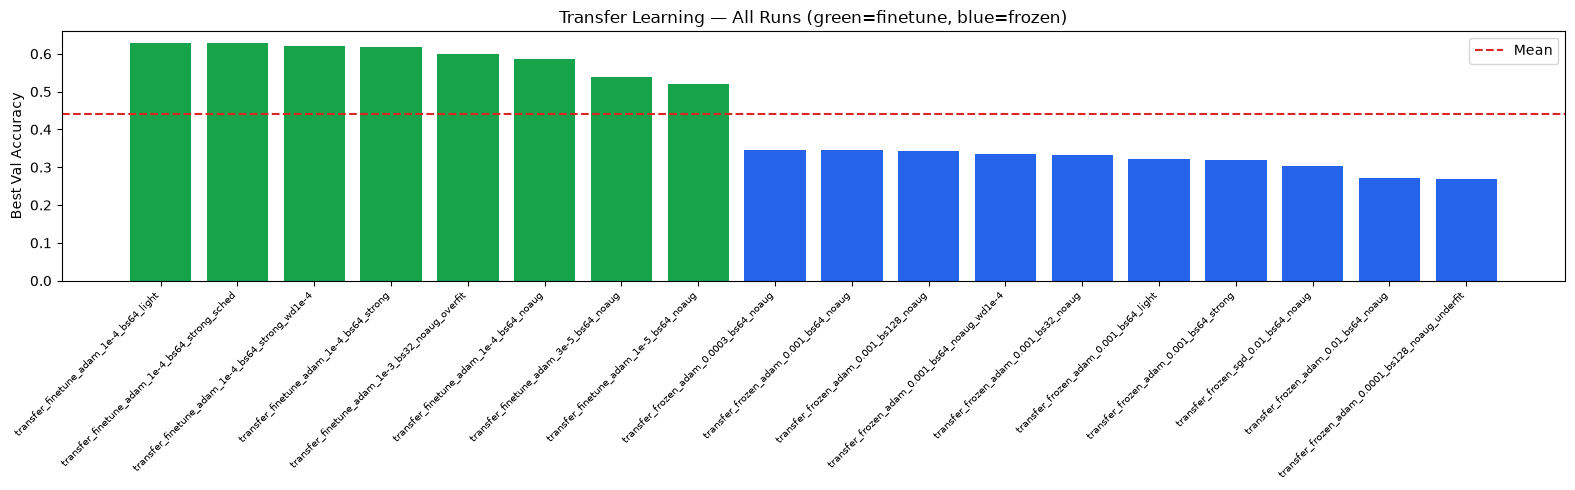

Generating charts:  14%|█▍        | 1/7 [00:00<00:05,  1.16it/s, current=Frozen vs Finetune]

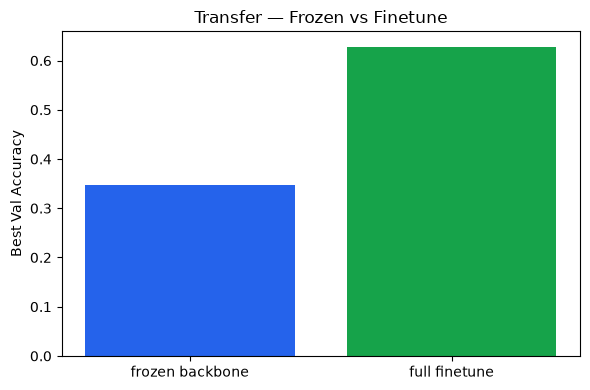

Generating charts:  29%|██▊       | 2/7 [00:01<00:02,  2.25it/s, current=LR Sweep Frozen]   

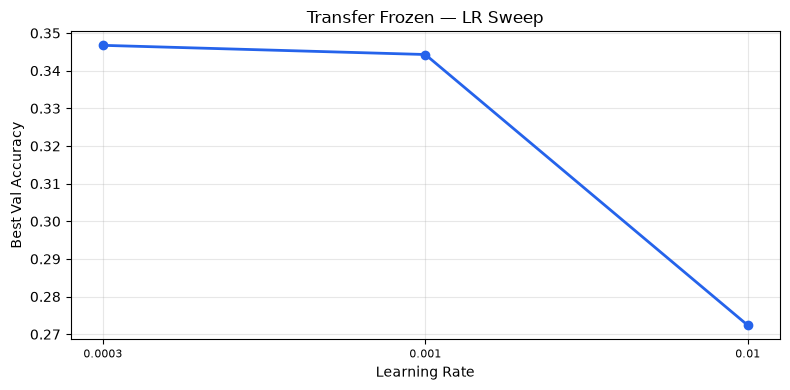

Generating charts:  43%|████▎     | 3/7 [00:01<00:01,  3.08it/s, current=LR Sweep Finetune]

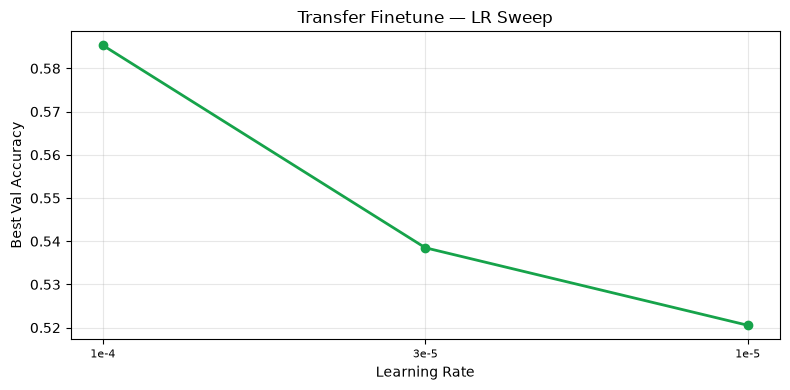

Generating charts:  57%|█████▋    | 4/7 [00:01<00:00,  3.79it/s, current=Augmentation]     

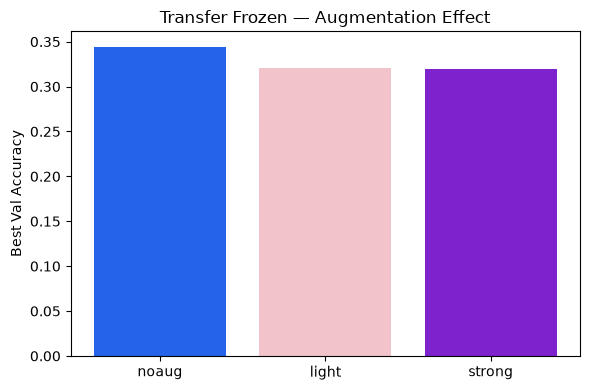

Generating charts:  71%|███████▏  | 5/7 [00:01<00:00,  4.45it/s, current=Best vs Overfit vs Underfit]

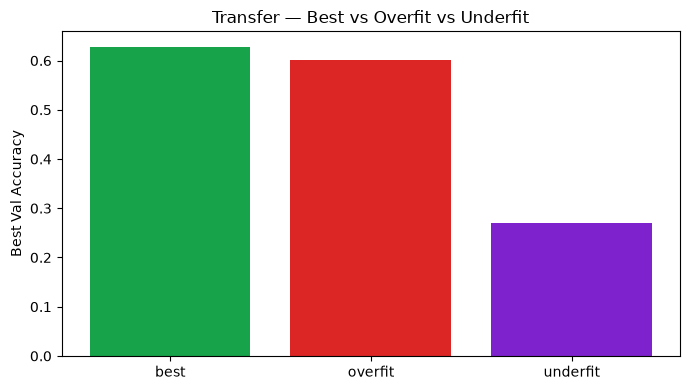

Generating charts:  86%|████████▌ | 6/7 [00:01<00:00,  5.02it/s, current=Confusion Matrix]           


Checkpoint: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints\transfer_finetune_adam_1e-4_bs64_light_best.pt
Exists: True


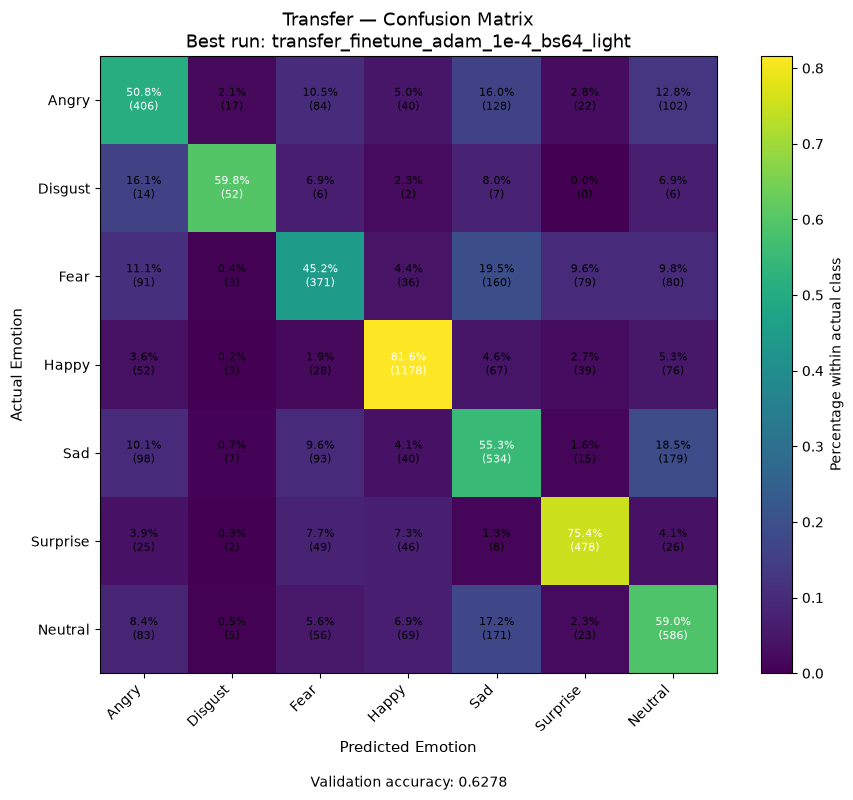

Generating charts: 100%|██████████| 7/7 [00:07<00:00,  1.11s/it, current=Confusion Matrix]



Best run: transfer_finetune_adam_1e-4_bs64_light
Best val_acc: 0.6280
All Transfer charts saved and logged to Wandb


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

BLUE   = '#2563EB'
PINK   = '#F3C3CB'
PURPLE = '#7E22CE'
RED    = '#DC2626'
GREEN  = '#16A34A'

results_df = pd.DataFrame(all_results).sort_values('best_val_acc', ascending=False)
print(results_df.to_string(index=False))

best_run_name = results_df.iloc[0]['run']
best_val_acc  = results_df.iloc[0]['best_val_acc']
print(f'\nBest run: {best_run_name} | val_acc: {best_val_acc:.4f}')

wandb.init(
    project='fer2013-expression-recognition',
    name='transfer_analysis',
    group='transfer',
    job_type='analysis'
)

charts = ['All Runs', 'Frozen vs Finetune', 'LR Sweep Frozen',
          'LR Sweep Finetune', 'Augmentation', 'Best vs Overfit vs Underfit',
          'Confusion Matrix']
chart_bar = tqdm(charts, desc='Generating charts')

for chart_name in chart_bar:
    chart_bar.set_postfix(current=chart_name)

    if chart_name == 'All Runs':
        fig, ax = plt.subplots(figsize=(16, 5))
        colors = [GREEN if 'finetune' in r else BLUE for r in results_df['run']]
        ax.bar(results_df['run'], results_df['best_val_acc'], color=colors)
        ax.axhline(y=results_df['best_val_acc'].mean(), color=RED, linestyle='--', label='Mean')
        ax.set_xticks(range(len(results_df)))
        ax.set_xticklabels(results_df['run'], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('Transfer Learning — All Runs (green=finetune, blue=frozen)')
        ax.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_bar.png'), dpi=200)
        wandb.log({'transfer_bar_chart': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Frozen vs Finetune':
        frozen_runs   = [r for r in all_results if 'frozen' in r['run'] and 'overfit' not in r['run'] and 'underfit' not in r['run']]
        finetune_runs = [r for r in all_results if 'finetune' in r['run'] and 'overfit' not in r['run'] and 'underfit' not in r['run']]
        frozen_best   = max(r['best_val_acc'] for r in frozen_runs)   if frozen_runs   else 0
        finetune_best = max(r['best_val_acc'] for r in finetune_runs) if finetune_runs else 0
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(['frozen backbone', 'full finetune'], [frozen_best, finetune_best], color=[BLUE, GREEN])
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('Transfer — Frozen vs Finetune')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_frozen_vs_finetune.png'), dpi=200)
        wandb.log({'transfer_frozen_vs_finetune': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'LR Sweep Frozen':
        lr_runs = [r for r in all_results if 'frozen' in r['run'] and 'adam' in r['run']
                   and 'noaug' in r['run'] and 'bs64' in r['run']
                   and 'wd' not in r['run'] and 'overfit' not in r['run'] and 'underfit' not in r['run']]
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(range(len(lr_runs)), [r['best_val_acc'] for r in lr_runs], 'o-', color=BLUE, linewidth=2)
        ax.set_xticks(range(len(lr_runs)))
        ax.set_xticklabels([r['run'].split('adam_')[1].split('_bs')[0] for r in lr_runs], fontsize=8)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('Transfer Frozen — LR Sweep')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_lr_frozen.png'), dpi=200)
        wandb.log({'transfer_lr_frozen': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'LR Sweep Finetune':
        lr_runs = [r for r in all_results if 'finetune' in r['run'] and 'adam' in r['run']
                   and 'noaug' in r['run'] and 'bs64' in r['run']
                   and 'wd' not in r['run'] and 'overfit' not in r['run'] and 'underfit' not in r['run']]
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(range(len(lr_runs)), [r['best_val_acc'] for r in lr_runs], 'o-', color=GREEN, linewidth=2)
        ax.set_xticks(range(len(lr_runs)))
        ax.set_xticklabels([r['run'].split('adam_')[1].split('_bs')[0] for r in lr_runs], fontsize=8)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('Transfer Finetune — LR Sweep')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_lr_finetune.png'), dpi=200)
        wandb.log({'transfer_lr_finetune': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Augmentation':
        aug_frozen = [
            ('noaug', next(r['best_val_acc'] for r in all_results if r['run'] == 'transfer_frozen_adam_0.001_bs64_noaug')),
            ('light', next(r['best_val_acc'] for r in all_results if r['run'] == 'transfer_frozen_adam_0.001_bs64_light')),
            ('strong',next(r['best_val_acc'] for r in all_results if r['run'] == 'transfer_frozen_adam_0.001_bs64_strong')),
        ]
        aug_labels, aug_vals = zip(*aug_frozen)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(aug_labels, aug_vals, color=[BLUE, PINK, PURPLE])
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('Transfer Frozen — Augmentation Effect')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_augmentation.png'), dpi=200)
        wandb.log({'transfer_augmentation': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Best vs Overfit vs Underfit':
        overfit_run  = next(r for r in all_results if 'overfit'  in r['run'])
        underfit_run = next(r for r in all_results if 'underfit' in r['run'])
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(
            ['best', 'overfit', 'underfit'],
            [best_val_acc, overfit_run['best_val_acc'], underfit_run['best_val_acc']],
            color=[GREEN, RED, PURPLE]
        )
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('Transfer — Best vs Overfit vs Underfit')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_overfit_underfit.png'), dpi=200)
        wandb.log({'transfer_overfit_underfit': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Confusion Matrix':
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'{best_run_name}_best.pt')
        print(f'\nCheckpoint: {checkpoint_path}')
        print(f'Exists: {os.path.exists(checkpoint_path)}')

        if not os.path.exists(checkpoint_path):
            print('Checkpoint missing — skipping confusion matrix')
        else:
            mode = 'finetune' if 'finetune' in best_run_name else 'frozen'
            _, val_loader, _ = get_dataloaders(data_dir=DATA_DIR, aug_mode='none', batch_size=128)
            model = TransferResNet18(mode=mode).to(DEVICE)
            model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
            model.eval()

            all_preds, all_labels_list = [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    outputs = model(images.to(DEVICE))
                    all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                    all_labels_list.extend(labels.numpy())

            all_preds = np.array(all_preds)
            all_labels_list = np.array(all_labels_list)
            val_accuracy = accuracy_score(all_labels_list, all_preds)

            wandb.log({
                'transfer_confusion_matrix_curve': wandb.plot.confusion_matrix(
                    y_true=all_labels_list,
                    preds=all_preds,
                    class_names=EMOTION_LABELS
                )
            })

            cm = confusion_matrix(all_labels_list, all_preds, labels=list(range(7)))
            cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True))

            fig, ax = plt.subplots(figsize=(10, 8))
            image = ax.imshow(cm_percent, interpolation='nearest')
            ax.set_title(f'Transfer — Confusion Matrix\nBest run: {best_run_name}', fontsize=13)
            ax.set_xlabel('Predicted Emotion', fontsize=11)
            ax.set_ylabel('Actual Emotion', fontsize=11)
            ax.set_xticks(np.arange(7))
            ax.set_yticks(np.arange(7))
            ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha='right')
            ax.set_yticklabels(EMOTION_LABELS)

            for i in range(7):
                for j in range(7):
                    ax.text(j, i,
                            f'{cm_percent[i,j]*100:.1f}%\n({cm[i,j]})',
                            ha='center', va='center', fontsize=8,
                            color='white' if cm_percent[i,j] > 0.45 else 'black')

            fig.colorbar(image, ax=ax).set_label('Percentage within actual class')
            fig.text(0.5, 0.01, f'Validation accuracy: {val_accuracy:.4f}', ha='center', fontsize=10)
            plt.tight_layout(rect=[0, 0.03, 1, 1])
            plt.savefig(os.path.join(CHECKPOINT_DIR, 'transfer_confusion_matrix.png'), dpi=200)
            wandb.log({'transfer_confusion_matrix_chart': wandb.Image(fig)})
            plt.show()

wandb.finish()
print(f'\nBest run: {best_run_name}')
print(f'Best val_acc: {best_val_acc:.4f}')
print('All Transfer charts saved and logged to Wandb')
